In [35]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

data = pd.read_csv(r"C:\Users\javie\OneDrive\Desktop\Excel_DB\customer_data.csv")
data.head()

,ID Cliente,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100),Categoría de Producto Favorito
0,1,56,89,47,Libros
1,2,69,91,86,Hogar
2,3,46,46,23,Electrónica
3,4,32,28,66,Libros
4,5,60,81,27,Electrónica


In [36]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   ID Cliente                      200 non-null    int64 
 1   Edad                            200 non-null    int64 
 2   Ingresos Anuales (k$)           200 non-null    int64 
 3   Puntuación de Gasto (1-100)     200 non-null    int64 
 4   Categoría de Producto Favorito  200 non-null    object
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [37]:
print(data.describe())

       ID Cliente       Edad  Ingresos Anuales (k$)  \
count  200.000000  200.00000             200.000000   
mean   100.500000   43.42500              69.580000   
std     57.879185   14.94191              29.693808   
min      1.000000   18.00000              20.000000   
25%     50.750000   31.00000              43.750000   
50%    100.500000   43.50000              69.500000   
75%    150.250000   56.00000              92.500000   
max    200.000000   69.00000             119.000000   

       Puntuación de Gasto (1-100)  
count                   200.000000  
mean                     49.910000  
std                      29.409292  
min                       1.000000  
25%                      24.000000  
50%                      50.000000  
75%                      74.000000  
max                      99.000000  


In [38]:
# Normalizar los datos 
escalador = MinMaxScaler()
data_escalada = escalador.fit_transform(data[['Edad','Ingresos Anuales (k$)', 'Puntuación de Gasto (1-100)']])
print(data_escalada)

[[0.74509804 0.6969697  0.46938776]
 [1.         0.71717172 0.86734694]
 [0.54901961 0.26262626 0.2244898 ]
 [0.2745098  0.08080808 0.66326531]
 [0.82352941 0.61616162 0.26530612]
 [0.1372549  0.36363636 0.01020408]
 [0.39215686 0.96969697 0.90816327]
 [0.74509804 0.50505051 0.16326531]
 [0.35294118 0.43434343 0.32653061]
 [0.43137255 0.23232323 0.08163265]
 [0.19607843 0.78787879 0.42857143]
 [0.19607843 0.58585859 0.47959184]
 [0.45098039 0.31313131 0.3877551 ]
 [0.68627451 0.95959596 0.93877551]
 [0.76470588 0.87878788 0.41836735]
 [0.45098039 0.51515152 0.25510204]
 [0.03921569 0.61616162 1.        ]
 [0.41176471 0.57575758 0.5       ]
 [0.01960784 0.51515152 0.24489796]
 [0.45098039 0.11111111 0.23469388]
 [0.84313725 0.38383838 0.12244898]
 [0.56862745 0.01010101 0.60204082]
 [0.7254902  0.02020202 0.06122449]
 [0.01960784 0.55555556 0.57142857]
 [0.39215686 0.80808081 0.35714286]
 [0.62745098 0.58585859 0.44897959]
 [0.21568627 0.01010101 0.19387755]
 [0.41176471 0.01010101 0.65

In [41]:
# Aplicar PCA
pca = PCA(n_components=2, random_state=42)
pca_resultados = pca.fit_transform(data_escalada)
# Aplicar SVD
U, Sigma, VT = np.linalg.svd(data_escalada)
# Seleccionar los dos primeros componentes singulares para reducción de dimensiones
k = 2
svd_resultados = U[:, :k] * Sigma[:k]

# Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(data_escalada)

# Aplicar Clustering Jerárquico 
linked = linkage(data_escalada, method='ward')

c:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


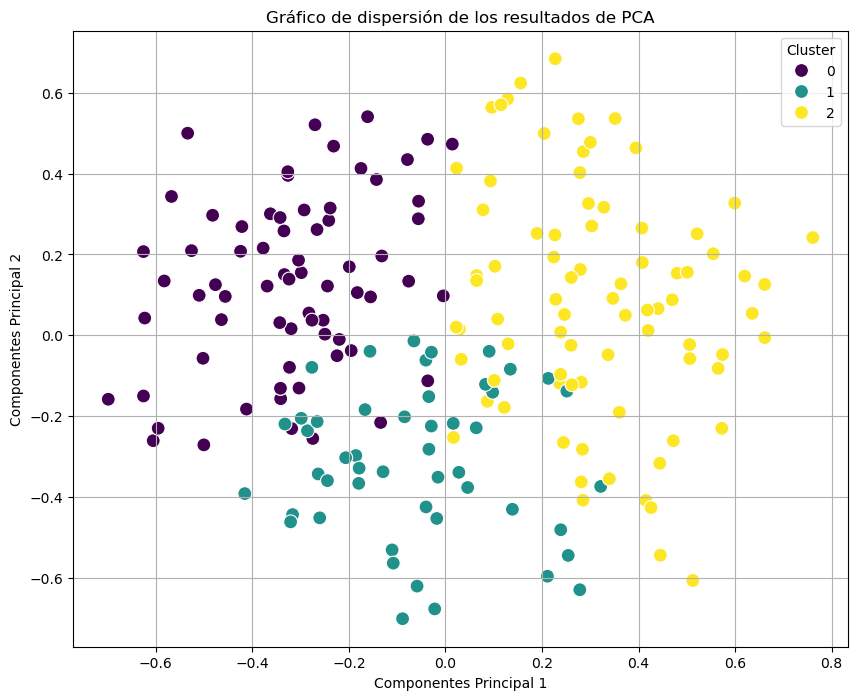

In [43]:
# VISUALIZACIÓN DE DATOS 

#Crear un gráfico de dispersión para los resultados de PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_resultados[:, 0 ], y=pca_resultados[:, 1], hue=kmeans_clusters, palette='viridis', s=100)
plt.title('Gráfico de dispersión de los resultados de PCA')
plt.xlabel('Componentes Principal 1')
plt.ylabel('Componentes Principal 2')
plt.legend(title='Cluster')
plt.grid(True)

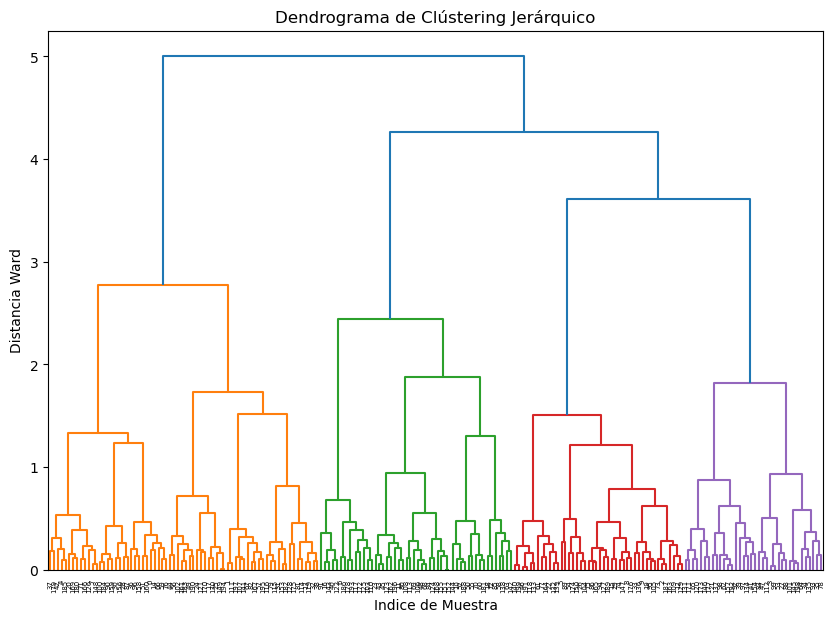

In [44]:

# Crear un dendrogramma del clústering jerárquico
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Dendrograma de Clústering Jerárquico')
plt.xlabel('Indice de Muestra')
plt.ylabel('Distancia Ward')
plt.axhline(y=10, color='r', linestyle='--')

In [45]:

# 5. INTERPRETACIÓN Y ESTRATEGIAS DE MARKETING BASADAS EN LOS CLUSTERS
# su edad media
#su ingresos medios
# su puntuación de gastos media

# Análisis de clusters para determinar estrategias
cluster_info = pd.DataFrame({
    'Cluster': kmeans_clusters,
    'Edad': data['Edad'],
    'Ingresos': data['Ingresos Anuales (k$)'],
    'Gasto': data['Puntuación de Gasto (1-100)']
})

# Descripción de cada clúster
for cluster in cluster_info['Cluster'].unique():
    cluster_data = cluster_info[cluster_info['Cluster'] == cluster]
    print(f"Cluster {cluster}:")
    print(f" - Edad Media: {cluster_data['Edad'].mean(): .0f}")
    print(f" - Ingresos Medios: {cluster_data['Ingresos'].mean(): .2f}")
    print(f" - Puntuación de Gasto Media: {cluster_data['Gasto'].mean(): .2f}")
    print()

Cluster 2:
 - Edad Media:  50
 - Ingresos Medios:  97.33
 - Puntuación de Gasto Media:  62.00

Cluster 0:
 - Edad Media:  43
 - Ingresos Medios:  52.51
 - Puntuación de Gasto Media:  20.17

Cluster 1:
 - Edad Media:  34
 - Ingresos Medios:  49.08
 - Puntuación de Gasto Media:  72.20



In [46]:

# 5. INTERPRETACIÓN Y ESTRATEGIAS DE MARKETING BASADAS EN LOS CLUSTERS
# su edad media
#su ingresos medios
# su puntuación de gastos media

# Análisis de clusters para determinar estrategias
cluster_info = pd.DataFrame({
    'Cluster': kmeans_clusters,
    'Edad': data['Edad'],
    'Ingresos': data['Ingresos Anuales (k$)'],
    'Gasto': data['Puntuación de Gasto (1-100)']
})

# Descripción de cada clúster
for cluster in cluster_info['Cluster'].unique():
    cluster_data = cluster_info[cluster_info['Cluster'] == cluster]
    print(f"Cluster {cluster}:")
    print(f" - Edad Media: {cluster_data['Edad'].mean(): .0f}")
    print(f" - Ingresos Medios: {cluster_data['Ingresos'].mean(): .2f}")
    print(f" - Puntuación de Gasto Media: {cluster_data['Gasto'].mean(): .2f}")
    print()


Cluster 2:
 - Edad Media:  50
 - Ingresos Medios:  97.33
 - Puntuación de Gasto Media:  62.00

Cluster 0:
 - Edad Media:  43
 - Ingresos Medios:  52.51
 - Puntuación de Gasto Media:  20.17

Cluster 1:
 - Edad Media:  34
 - Ingresos Medios:  49.08
 - Puntuación de Gasto Media:  72.20

